In [1]:
import matplotlib.pyplot as plt
import numpy as np

from gtf import constants
from gtf import state
from gtf import jacobian
from gtf import newton
from gtf import initial_conditions
from gtf import residual

In [2]:
r_first = constants.FLOATDTYPE(0.001)

constants.R_OUTER = constants.FLOATDTYPE(200.0)
constants.N_SHELL = 200

In [3]:
ln_r_edge, u = initial_conditions.set_up_initial_conditions(r_first)

In [4]:
constants.SIGMA_OVER_M = constants.FLOATDTYPE(0.3)
constants.BETA = constants.FLOATDTYPE(0.8)
constants.ALPHA = constants.FLOATDTYPE(1.0)

In [5]:
state_init = state.state_from_unknowns(ln_r_edge, u)

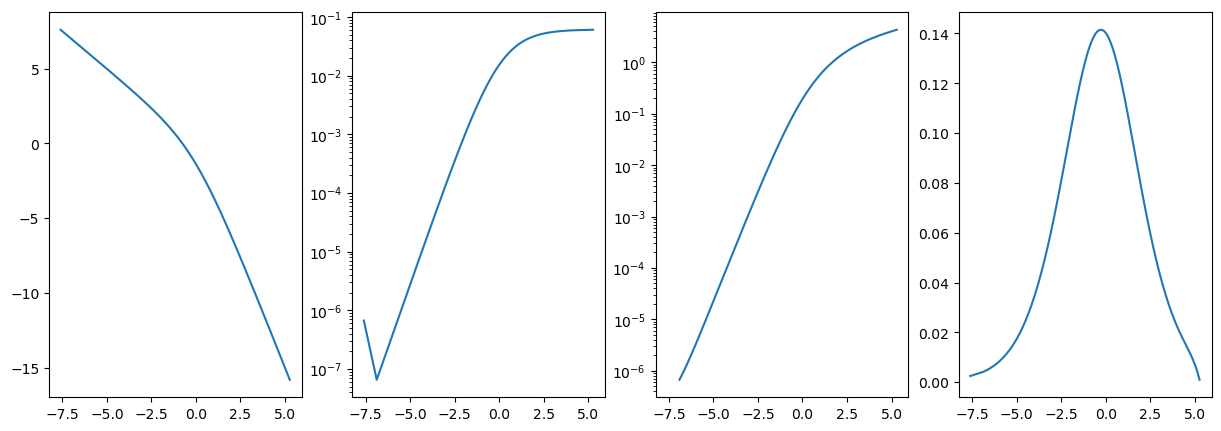

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(15, 5), sharex="all")
ax[0].plot(state_init["ln_r"], state_init["ln_rho"])
ax[1].plot(state_init["ln_r"], constants.DM)
ax[2].plot(ln_r_edge, constants.M_EDGE)
ax[3].plot(state_init["ln_r"], state_init["u"])

ax[1].set_yscale("log")
ax[2].set_yscale("log")

In [7]:
def residual_for_numerical_jacobian(x, v_old, u_old, dt):
    ln_r_edge, u = newton.unpack_unknowns(x)
    state_curr = state.state_from_unknowns(ln_r_edge, u)
    return residual.residual(state_curr, v_old, u_old, dt)

In [8]:
def numerical_jacobian(F, x, step, *args):

    J = np.empty((len(x), len(x)), dtype=constants.FLOATDTYPE)

    for j in range(len(x)):
        h = step

        x_plus = x.copy()
        x_minus = x.copy()

        x_plus[j] += h
        x_minus[j] -= h

        J[:, j] = (F(x_plus, *args) - F(x_minus, *args)) / (2.0 * h)

    return J

In [9]:
v_old = state_init["v"]
u_old = state_init["u"]
dt = 0.001

point = np.concatenate((ln_r_edge[1:-1], u))

jac_num = numerical_jacobian(
    residual_for_numerical_jacobian, point, 1e-7, v_old, u_old, dt
)

In [10]:
jac = jacobian.analytic_jacobian(state_init, v_old, dt)

In [11]:
#hydro with respect to ln_redge

a = 0
b = constants.N_SHELL - 1
c = 0
d = constants.N_SHELL - 1

abs_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d])

mask = jac[a:b, c:d] != 0
rel_err = abs_err[mask] / np.abs(jac[a:b, c:d][mask])

np.max(rel_err), np.max(abs_err)

(3.6321321267460635e-09, 1.834384363519348e-06)

In [12]:
#hydro with respect to u

a = 0
b = constants.N_SHELL - 1
c = constants.N_SHELL - 1
d = 2 * constants.N_SHELL

abs_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d])

mask = jac[a:b, c:d] != 0
rel_err = abs_err[mask] / np.abs(jac[a:b, c:d][mask])

np.max(rel_err), np.max(abs_err)

(4.521491169283591e-09, 5.036539914726745e-05)

In [13]:
#energy with respect to ln_redge

a = constants.N_SHELL - 1
b = 2 * constants.N_SHELL
c = 0
d = constants.N_SHELL - 1

abs_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d])

mask = jac[a:b, c:d] != 0
rel_err = abs_err[mask] / np.abs(jac[a:b, c:d][mask])

np.max(rel_err), np.max(abs_err)

(1.1503005967225505e-06, 2.4040196500152433e-09)

In [14]:
#energy with respect to u

a = constants.N_SHELL - 1
b = 2 * constants.N_SHELL
c = constants.N_SHELL - 1
d = 2 * constants.N_SHELL

abs_err = np.abs(jac[a:b, c:d] - jac_num[a:b, c:d])

mask = jac[a:b, c:d] != 0
rel_err = abs_err[mask] / np.abs(jac[a:b, c:d][mask])

np.max(rel_err), np.max(abs_err)

(1.3040069466109405e-09, 9.430536351828778e-10)